In [2]:
import re
import math
import torch
import torch.nn as nn
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt


In [3]:
from tqdm import tqdm
import time


In [4]:
def load_text(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

text = load_text("data/text.txt")
print(text[:500])


the project gutenberg ebook of adventures of sherlock holmes
    
this ebook is for the use of anyone anywhere in the united states and
most other parts of the world at no cost and with almost no restrictions
whatsoever you may copy it give it away or reuse it under the terms
of the project gutenberg license included with this ebook or online
at wwwgutenbergorg if you are not located in the united states
you will have to check the laws of the country where you are located
before using this ebook


In [5]:
def build_vocab(text, min_freq=2):
    words = text.split()
    freq = Counter(words)

    vocab = {w for w, c in freq.items() if c >= min_freq}
    word2idx = {w: i+1 for i, w in enumerate(vocab)}
    word2idx["<PAD>"] = 0
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word

word2idx, idx2word = build_vocab(text)
encoded = [word2idx[w] for w in text.split() if w in word2idx]


In [6]:
SEQ_LEN = 20

X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i:i+SEQ_LEN])
    y.append(encoded[i+SEQ_LEN])

X = torch.tensor(X)
y = torch.tensor(y)

print(X.shape, y.shape)


torch.Size([105036, 20]) torch.Size([105036])


In [7]:
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1]
        return self.fc(out)


In [8]:
class TransformerTextGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, n_heads=4, n_layers=2, max_len=200):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.embedding(x) + self.pos_embedding(pos)
        x = self.transformer(x)
        return self.fc(x[:, -1])


In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = nn.CrossEntropyLoss()

def train_model(model, epochs=90, batch_size=64):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_history = []

    total_start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_start = time.time()
        total_loss = 0

        progress_bar = tqdm(
            range(0, len(X), batch_size),
            desc=f"Epoch {epoch+1}/{epochs}",
            leave=False
        )

        for i in progress_bar:
            xb = X[i:i+batch_size].to(device)
            yb = y[i:i+batch_size].to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            progress_bar.set_postfix(loss=loss.item())

        avg_loss = total_loss / (len(X) // batch_size)
        loss_history.append(avg_loss)

        epoch_time = time.time() - epoch_start
        elapsed_time = time.time() - total_start_time
        avg_epoch_time = elapsed_time / (epoch + 1)
        remaining_time = avg_epoch_time * (epochs - epoch - 1)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Time: {epoch_time:.1f}s | "
            f"ETA: {remaining_time/60:.1f} min"
        )

    total_time = time.time() - total_start_time
    print(f"\nTraining completed in {total_time/60:.2f} minutes")

    return loss_history


In [10]:
lstm_model = LSTMTextGenerator(len(word2idx))
lstm_loss = train_model(lstm_model, epochs=90)

torch.save({
    "model_state": lstm_model.state_dict(),
    "word2idx": word2idx,
    "idx2word": idx2word
}, "lstm_model.pth")


Epoch 1/90 | Loss: 5.8263 | Time: 93.7s | ETA: 138.9 min


Epoch 2/90 | Loss: 5.0112 | Time: 88.9s | ETA: 133.8 min


Epoch 3/90 | Loss: 4.5141 | Time: 87.9s | ETA: 130.7 min


Epoch 4/90 | Loss: 4.0658 | Time: 88.4s | ETA: 128.6 min


Epoch 5/90 | Loss: 3.6534 | Time: 90.7s | ETA: 127.4 min


...

Epoch 86/90 | Loss: 0.2485 | Time: 140.3s | ETA: 6.2 min


Epoch 87/90 | Loss: 0.2466 | Time: 139.9s | ETA: 4.7 min


Epoch 88/90 | Loss: 0.2577 | Time: 137.9s | ETA: 3.1 min


Epoch 89/90 | Loss: 0.2512 | Time: 137.6s | ETA: 1.6 min


Epoch 90/90 | Loss: 0.2466 | Time: 138.2s | ETA: 0.0 min

Training completed in 142.85 minutes


In [11]:
transformer_model = TransformerTextGenerator(len(word2idx))
transformer_loss = train_model(transformer_model, epochs=50)

torch.save({
    "model_state": transformer_model.state_dict(),
    "word2idx": word2idx,
    "idx2word": idx2word
}, "transformer_model.pth")


Epoch 1/50 | Loss: 5.8264 | Time: 329.4s | ETA: 269.0 min


Epoch 2/50 | Loss: 5.1597 | Time: 330.4s | ETA: 263.9 min


Epoch 3/50 | Loss: 4.8367 | Time: 328.9s | ETA: 258.2 min


Epoch 4/50 | Loss: 4.5858 | Time: 329.7s | ETA: 252.7 min


Epoch 5/50 | Loss: 4.3820 | Time: 329.1s | ETA: 247.1 min


...

Epoch 46/50 | Loss: 1.9985 | Time: 204.4s | ETA: 14.7 min


Epoch 47/50 | Loss: 1.9750 | Time: 243.8s | ETA: 11.1 min


Epoch 48/50 | Loss: 1.9575 | Time: 245.3s | ETA: 7.4 min


Epoch 49/50 | Loss: 1.9314 | Time: 228.4s | ETA: 3.7 min


Epoch 50/50 | Loss: 1.9135 | Time: 254.3s | ETA: 0.0 min

Training completed in 185.29 minutes


In [12]:
def sample_with_temperature(probs, temperature=0.8):
    probs = np.log(probs + 1e-9) / temperature
    probs = np.exp(probs)
    probs /= probs.sum()
    return np.random.choice(len(probs), p=probs)


In [13]:
def generate_text(model, prompt, length=30, temperature=0.8):
    words = prompt.lower().split()
    current = [word2idx.get(w, 0) for w in words][-SEQ_LEN:]

    model.eval()
    for _ in range(length):
        x = torch.tensor([current]).to(device)
        with torch.no_grad():
            preds = model(x)
            probs = torch.softmax(preds, dim=1).cpu().numpy()[0]

        idx = sample_with_temperature(probs, temperature)
        words.append(idx2word.get(idx, ""))
        current.append(idx)
        current = current[-SEQ_LEN:]

    return " ".join(words)


In [14]:
def calculate_perplexity(model):
    model.eval()
    total_loss, total_samples = 0, 0

    with torch.no_grad():
        for i in range(0, len(X), 64):
            xb = X[i:i+64].to(device)
            yb = y[i:i+64].to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            total_loss += loss.item() * len(xb)
            total_samples += len(xb)

    avg_loss = total_loss / total_samples
    return math.exp(avg_loss)

print("LSTM Perplexity:", calculate_perplexity(lstm_model))
print("Transformer Perplexity:", calculate_perplexity(transformer_model))


LSTM Perplexity: 1.403674380162697
Transformer Perplexity: 7.57273640495207


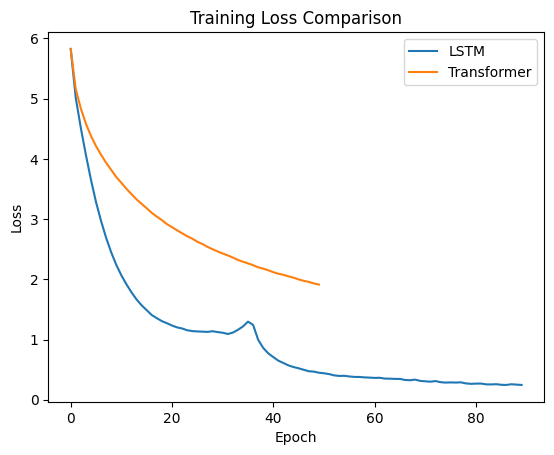

In [15]:
plt.plot(lstm_loss, label="LSTM")
plt.plot(transformer_loss, label="Transformer")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()
